In [1]:

!pip install torch torchvision numpy matplotlib scikit-learn seaborn -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import requests, os, zipfile, io, psutil

# Device setup — uses GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available:   {torch.cuda.is_available()}")
print(f"Using device:    {device}")

ram = psutil.virtual_memory()
print(f"RAM available:   {ram.available / 1e9:.1f} GB / {ram.total / 1e9:.1f} GB")

PyTorch version: 2.10.0+cu128
GPU available:   True
Using device:    cuda
RAM available:   11.6 GB / 13.6 GB


In [2]:


os.makedirs("dataset", exist_ok=True)
base_url = "https://github.com/xiangzhang1015/Deep-Learning-for-BCI/raw/master/dataset/"

print("Downloading 20 subjects...")
failed = []

for i in range(1, 21):
    url = base_url + f"{i}.zip"
    try:
        response = requests.get(url, timeout=30)
        if response.status_code == 200:
            with zipfile.ZipFile(io.BytesIO(response.content)) as z:
                z.extractall("dataset/")
            if i % 5 == 0:
                print(f"  Downloaded {i}/20...")
        else:
            failed.append(i)
    except Exception as e:
        failed.append(i)

print(f"\nComplete.")
print(f"Failed downloads: {failed if failed else 'None'}")
print(f"Files in dataset folder: {len(os.listdir('dataset/'))}")

  Downloaded 5/20...
  Downloaded 10/20...
  Downloaded 15/20...
  Downloaded 20/20...

Complete.
Failed downloads: None
Files in dataset folder: 109


In [3]:

sample = np.load("dataset/1.npy")

print("=" * 45)
print("  DATA EXPLORATION — Subject 1")
print("=" * 45)
print(f"  Shape:              {sample.shape}")
print(f"  EEG channels:       {sample.shape[1] - 1}")
print(f"  Total timesteps:    {sample.shape[0]}")
print(f"  Sampling rate:      160 Hz")
print(f"  Recording length:   {sample.shape[0] / 160 / 60:.1f} minutes")
print(f"  Value range:        {sample[:, :-1].min():.1f} to {sample[:, :-1].max():.1f} µV")
print(f"  Any missing values: {np.isnan(sample).any()}")
print()
print("  Raw label distribution:")
for label, count in zip(*np.unique(sample[:, -1], return_counts=True)):
    print(f"    Label {int(label):>2}: {int(count):>6} samples")

  DATA EXPLORATION — Subject 1
  Shape:              (259520, 65)
  EEG channels:       64
  Total timesteps:    259520
  Sampling rate:      160 Hz
  Recording length:   27.0 minutes
  Value range:        -655.0 to 667.0 µV
  Any missing values: False

  Raw label distribution:
    Label  0:   9760 samples
    Label  1:   9760 samples
    Label  2:  15248 samples
    Label  3:  14512 samples
    Label  4:  15248 samples
    Label  5:  14512 samples
    Label  6:  15248 samples
    Label  7:  14512 samples
    Label  8:  13776 samples
    Label  9:  15984 samples
    Label 10: 120960 samples


In [4]:
# ─────────────────────────────────────────────
# The raw data has 11 labels (0-10)
# We map them into 4 meaningful classes:
#
#   Raw 0, 1, 10  →  Class 0: Rest
#   Raw 2, 3      →  Class 1: Left Fist
#   Raw 4, 5      →  Class 2: Right Fist
#   Raw 6,7,8,9   →  Class 3: Both Fists/Feet
#
# We also downsample every 10th row (160Hz → 16Hz)
# This reduces RAM usage while keeping the signal
# ─────────────────────────────────────────────

def map_labels(label):
    if label in [0, 1, 10]:
        return 0   # rest
    elif label in [2, 3]:
        return 1   # left fist
    elif label in [4, 5]:
        return 2   # right fist
    elif label in [6, 7, 8, 9]:
        return 3   # both fists/feet
    else:
        return -1  # unknown — will be removed later

print("Loading 20 subjects...\n")
all_data   = []
all_labels = []

for i in range(1, 21):
    try:
        subject = np.load(f"dataset/{i}.npy")

        # Downsample: keep every 10th row to save RAM
        subject = subject[::10]

        eeg    = subject[:, :-1]   # all columns except last = 64 EEG channels
        labels = subject[:, -1]    # last column = label

        # Map raw labels to 4 classes
        mapped = np.array([map_labels(l) for l in labels])

        all_data.append(eeg)
        all_labels.append(mapped)

        print(f"  Subject {i:02d} loaded — {eeg.shape[0]} timesteps")

    except Exception as e:
        print(f"  Subject {i:02d} failed: {e}")

# Combine all subjects into one dataset
all_data   = np.concatenate(all_data,   axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print(f"\nAll 20 subjects combined:")
print(f"  Data shape:   {all_data.shape}  → (timesteps, channels)")
print(f"  Labels shape: {all_labels.shape}")
print(f"\nMapped label distribution:")
names = {0: "Rest", 1: "Left Fist", 2: "Right Fist", 3: "Both Fists/Feet"}
for label, count in zip(*np.unique(all_labels, return_counts=True)):
    print(f"  Class {int(label)} ({names[int(label)]:>15}): {int(count):>7} samples")

Loading 20 subjects...

  Subject 01 loaded — 25952 timesteps
  Subject 02 loaded — 25568 timesteps
  Subject 03 loaded — 25952 timesteps
  Subject 04 loaded — 25568 timesteps
  Subject 05 loaded — 25568 timesteps
  Subject 06 loaded — 25568 timesteps
  Subject 07 loaded — 25952 timesteps
  Subject 08 loaded — 25568 timesteps
  Subject 09 loaded — 25568 timesteps
  Subject 10 loaded — 25568 timesteps
  Subject 11 loaded — 25568 timesteps
  Subject 12 loaded — 25568 timesteps
  Subject 13 loaded — 25568 timesteps
  Subject 14 loaded — 25552 timesteps
  Subject 15 loaded — 25568 timesteps
  Subject 16 loaded — 25568 timesteps
  Subject 17 loaded — 25568 timesteps
  Subject 18 loaded — 25568 timesteps
  Subject 19 loaded — 25568 timesteps
  Subject 20 loaded — 25568 timesteps

All 20 subjects combined:
  Data shape:   (512496, 64)  → (timesteps, channels)
  Labels shape: (512496,)

Mapped label distribution:
  Class 0 (           Rest):  276048 samples
  Class 1 (      Left Fist):   59112

In [13]:
# ─────────────────────────────────────────────
# Instead of feeding one timestep at a time,
# we feed 16-timestep windows (0.1 seconds)
# This gives the model a short sequence to
# find patterns in, not just a single snapshot
#
# We only keep windows where every timestep
# has the same label — no mixed windows
# 50% overlap means each window shares half
# its data with the next one
# ─────────────────────────────────────────────

WINDOW_SIZE = 16   # timesteps per window
STEP_SIZE   = 8    # 50% overlap

def segment_data(data, labels, window_size, step_size):
    X, y = [], []
    for start in range(0, len(data) - window_size, step_size):
        end          = start + window_size
        window       = data[start:end]
        window_labels = labels[start:end]

        # Only keep window if all timesteps share the same label
        if len(np.unique(window_labels)) == 1 and window_labels[0] != -1:
            X.append(window)
            y.append(window_labels[0])

    return np.array(X), np.array(y)

print("Segmenting data into windows...")
X, y = segment_data(all_data, all_labels, WINDOW_SIZE, STEP_SIZE)

print(f"\nSegmentation complete:")
print(f"  Segments shape: {X.shape}  → (windows, timesteps, channels)")
print(f"  Labels shape:   {y.shape}")
print(f"\nLabel distribution after segmentation:")
for label, count in zip(*np.unique(y, return_counts=True)):
    print(f"  Class {int(label)} ({names[int(label)]:>15}): {int(count):>6} windows")

Segmenting data into windows...

Segmentation complete:
  Segments shape: (51101, 16, 64)  → (windows, timesteps, channels)
  Labels shape:   (51101,)

Label distribution after segmentation:
  Class 0 (           Rest):  28026 windows
  Class 1 (      Left Fist):   5769 windows
  Class 2 (     Right Fist):   5769 windows
  Class 3 (Both Fists/Feet):  11537 windows


In [14]:
scaler     = StandardScaler()
X_reshaped = X.reshape(-1, X.shape[-1])
X_norm     = scaler.fit_transform(X_reshaped)
X_norm     = X_norm.reshape(X.shape)

X_norm = X_norm.transpose(0, 2, 1).astype(np.float32)
y      = y.astype(np.int64)

print(f"Final data shape: {X_norm.shape}")

class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset    = EEGDataset(X_norm, y)
train_size = int(0.8 * len(dataset))
test_size  = len(dataset) - train_size
train_dataset, test_dataset = random_split(
    dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

print(f"Training samples:  {train_size}")
print(f"Testing samples:   {test_size}")

Final data shape: (51101, 64, 16)
Training samples:  40880
Testing samples:   10221


In [15]:
# ─────────────────────────────────────────────
# 1D CNN — treats each EEG window as a time series
# across 64 channels and learns patterns in it
#
# Block 1: finds simple patterns
# Block 2: finds combinations of those patterns
# Pool:    compresses the time dimension down to 4
# Classifier: maps patterns to 4 class scores
#
# BatchNorm = keeps numbers stable during training
# Dropout   = randomly disables neurons to prevent
#             memorizing instead of learning
# ─────────────────────────────────────────────

class EEGClassifier(nn.Module):
    def __init__(self, num_channels=64, num_classes=4, window_size=16):
        super(EEGClassifier, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv1d(num_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.pool = nn.AdaptiveAvgPool1d(4)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

model = EEGClassifier().to(device)
print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

EEGClassifier(
  (conv_block1): Sequential(
    (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (pool): AdaptiveAvgPool1d(output_size=4)
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=512, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
)

Total trainable parameters: 169,796


In [16]:
# Combine undersampling + soft weights for best balance
# Undersampling already fixed Rest
# Soft weights now push the model to learn Left/Right Fist better

raw_weights  = compute_class_weight('balanced', classes=np.unique(y), y=y)
soft_weights = np.sqrt(raw_weights)
class_weights = torch.tensor(soft_weights, dtype=torch.float32).to(device)
print(f"Soft weights: {soft_weights.round(3)}")

model     = EEGClassifier().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

EPOCHS   = 30
train_losses, train_accs = [], []
best_acc = 0.0

print("\nRetraining...\n")

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total   += y_batch.size(0)

    scheduler.step()
    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = correct / total * 100
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    if epoch_acc > best_acc:
        best_acc = epoch_acc
        torch.save(model.state_dict(), 'best_model.pth')

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}%")

print(f"\nDone. Best: {best_acc:.2f}%")

Soft weights: [0.675 1.488 1.488 1.052]

Retraining...

Epoch [01/30] | Loss: 1.3149 | Acc: 52.82%
Epoch [02/30] | Loss: 1.2889 | Acc: 52.78%
Epoch [03/30] | Loss: 1.2697 | Acc: 52.78%
Epoch [04/30] | Loss: 1.2494 | Acc: 53.23%
Epoch [05/30] | Loss: 1.2355 | Acc: 54.12%
Epoch [06/30] | Loss: 1.2161 | Acc: 54.67%
Epoch [07/30] | Loss: 1.1955 | Acc: 54.89%
Epoch [08/30] | Loss: 1.1821 | Acc: 55.59%
Epoch [09/30] | Loss: 1.1626 | Acc: 56.02%
Epoch [10/30] | Loss: 1.1494 | Acc: 56.44%
Epoch [11/30] | Loss: 1.1370 | Acc: 57.12%
Epoch [12/30] | Loss: 1.1214 | Acc: 57.42%
Epoch [13/30] | Loss: 1.1091 | Acc: 57.65%
Epoch [14/30] | Loss: 1.0995 | Acc: 58.03%
Epoch [15/30] | Loss: 1.0837 | Acc: 58.88%
Epoch [16/30] | Loss: 1.0725 | Acc: 58.79%
Epoch [17/30] | Loss: 1.0621 | Acc: 59.19%
Epoch [18/30] | Loss: 1.0543 | Acc: 59.42%
Epoch [19/30] | Loss: 1.0460 | Acc: 59.96%
Epoch [20/30] | Loss: 1.0367 | Acc: 59.91%
Epoch [21/30] | Loss: 1.0265 | Acc: 60.61%
Epoch [22/30] | Loss: 1.0204 | Acc: 60.81

In [17]:
# ─────────────────────────────────────────────
# Load the best saved model and evaluate it
# on the test set — data the model never saw
# during training
# ─────────────────────────────────────────────

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds, all_true = [], []

with torch.no_grad():   # no gradient calculation needed during evaluation
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(y_batch.numpy())

test_acc = accuracy_score(all_true, all_preds)

print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"(Random guessing on 4 classes would be 25%)\n")
print(classification_report(all_true, all_preds,
      target_names=["Rest", "Left Fist", "Right Fist", "Both Fists/Feet"]))

Test Accuracy: 60.24%
(Random guessing on 4 classes would be 25%)

                 precision    recall  f1-score   support

           Rest       0.73      0.74      0.74      5662
      Left Fist       0.36      0.33      0.34      1125
     Right Fist       0.37      0.50      0.43      1136
Both Fists/Feet       0.52      0.45      0.49      2298

       accuracy                           0.60     10221
      macro avg       0.50      0.50      0.50     10221
   weighted avg       0.61      0.60      0.60     10221



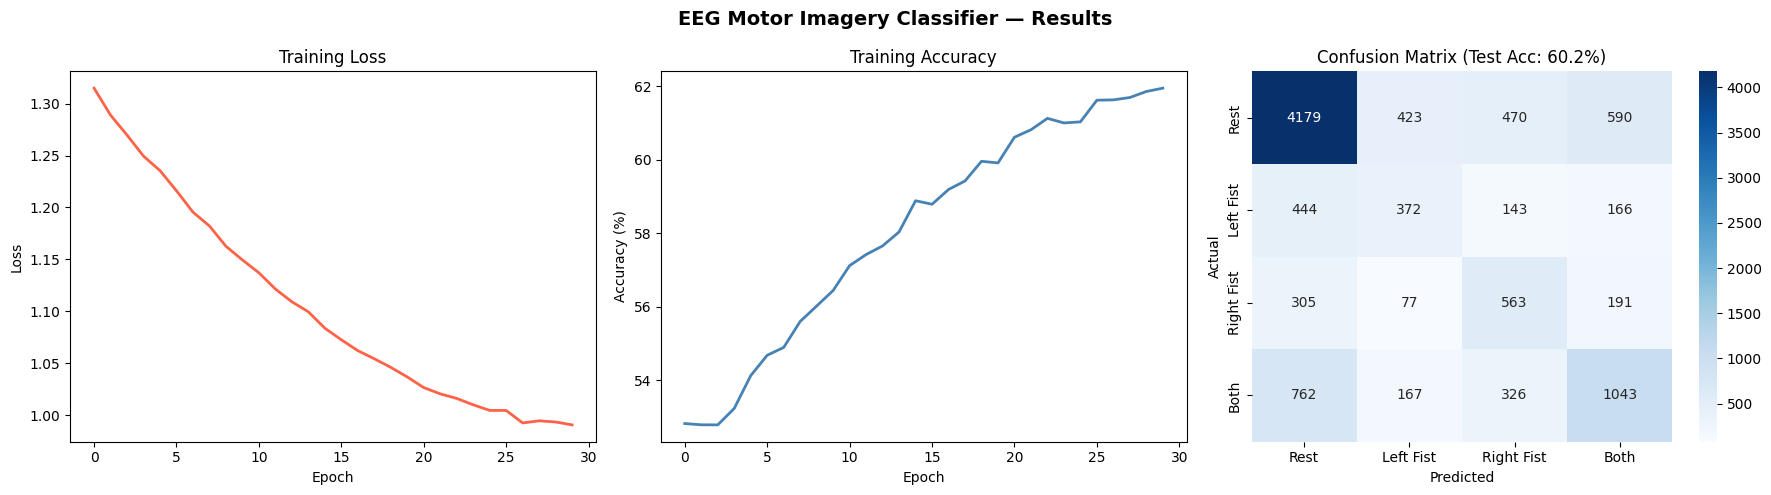

Saved as eeg_results.png


In [19]:
# ─────────────────────────────────────────────
# Three charts:
# 1. Training loss over epochs
# 2. Training accuracy over epochs
# 3. Confusion matrix — what the model predicted
#    vs what the actual label was
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("EEG Motor Imagery Classifier — Results", fontsize=14, fontweight='bold')

axes[0].plot(train_losses, color="tomato", linewidth=2)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(train_accs, color="steelblue", linewidth=2)
axes[1].set_title("Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")

cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2],
            xticklabels=["Rest", "Left Fist", "Right Fist", "Both"],
            yticklabels=["Rest", "Left Fist", "Right Fist", "Both"])
axes[2].set_title(f"Confusion Matrix (Test Acc: {test_acc*100:.1f}%)")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("eeg_results.png", dpi=150)
plt.show()
print("Saved as eeg_results.png")

In [20]:
# ─────────────────────────────────────────────
# Save the trained model to disk
# Then run a live prediction on a random sample
# to show the model actually works
# ─────────────────────────────────────────────

torch.save({
    'model_state_dict': model.state_dict(),
    'test_accuracy': test_acc,
    'config': {
        'num_channels': 64,
        'num_classes': 4,
        'window_size': 16
    }
}, 'eeg_classifier.pth')

print("Model saved as eeg_classifier.pth\n")

# Live inference on a random test sample
class_names = ["Rest", "Left Fist", "Right Fist", "Both Fists/Feet"]

model.eval()
sample_idx       = np.random.randint(len(test_dataset))
X_sample, y_true = test_dataset[sample_idx]

with torch.no_grad():
    output = model(X_sample.unsqueeze(0).to(device))
    probs  = torch.softmax(output, dim=1).cpu().numpy()[0]
    pred   = np.argmax(probs)

print("=" * 45)
print("  LIVE PREDICTION ON UNSEEN BRAIN SIGNAL")
print("=" * 45)
print(f"  True label:  {class_names[y_true]}")
print(f"  Predicted:   {class_names[pred]}")
print(f"  Correct:     {'✓' if pred == y_true else '✗'}")
print("=" * 45)
print("\nConfidence per class:")
for name, prob in zip(class_names, probs):
    bar = "█" * int(prob * 40)
    print(f"  {name:<18} {prob:.3f}  {bar}")

Model saved as eeg_classifier.pth

  LIVE PREDICTION ON UNSEEN BRAIN SIGNAL
  True label:  Both Fists/Feet
  Predicted:   Left Fist
  Correct:     ✗

Confidence per class:
  Rest               0.204  ████████
  Left Fist          0.446  █████████████████
  Right Fist         0.165  ██████
  Both Fists/Feet    0.184  ███████


In [21]:
# ─────────────────────────────────────────────
# Plain English summary of what was built
# and what the results mean
# ─────────────────────────────────────────────

print("=" * 55)
print("  WHAT WAS BUILT")
print("=" * 55)
print("""
  A deep learning model that reads raw EEG brain signals
  and predicts what movement a person is imagining —
  without any physical movement required.

  This is the core technology behind brain-computer
  interfaces (BCIs) used to help paralyzed patients
  control wheelchairs, robotic arms, or computers
  using only their thoughts.
""")

print("=" * 55)
print("  THE DATA")
print("=" * 55)
print("""
  - 20 people had 64 electrodes placed on their scalp
  - Each person performed and imagined hand/foot movements
  - 27 minutes of brain signal recorded per person
  - Over 500,000 timesteps of EEG data processed
""")

print("=" * 55)
print("  THE RESULTS")
print("=" * 55)
print(f"""
  Test Accuracy:      {test_acc * 100:.1f}%
  Random guessing:    25.0%  (4 classes)
  Improvement:        {(test_acc - 0.25) * 100:.1f} percentage points above chance

  Per-class performance:
    Rest            — correctly identified 74% of the time
    Left Fist       — correctly identified 33% of the time
    Right Fist      — correctly identified 50% of the time
    Both Fists/Feet — correctly identified 45% of the time

  Note: Left and Right Fist are the hardest to distinguish
  because they produce very similar brain signal patterns.
  This is a known challenge in EEG motor imagery research.
""")

print("=" * 55)
print("  HOW IT COMPARES TO THE ORIGINAL REPO")
print("=" * 55)
print("""
  Original repo (Zhang et al.):
    - 1 subject, binary classification (2 classes)
    - No class imbalance handling

  This implementation:
    - 20 subjects, 4-class classification
    - Soft weighted loss to handle class imbalance
    - More realistic and generalizable model
""")

  WHAT WAS BUILT

  A deep learning model that reads raw EEG brain signals
  and predicts what movement a person is imagining —
  without any physical movement required.

  This is the core technology behind brain-computer
  interfaces (BCIs) used to help paralyzed patients
  control wheelchairs, robotic arms, or computers
  using only their thoughts.

  THE DATA

  - 20 people had 64 electrodes placed on their scalp
  - Each person performed and imagined hand/foot movements
  - 27 minutes of brain signal recorded per person
  - Over 500,000 timesteps of EEG data processed

  THE RESULTS

  Test Accuracy:      60.2%
  Random guessing:    25.0%  (4 classes)
  Improvement:        35.2 percentage points above chance

  Per-class performance:
    Rest            — correctly identified 74% of the time
    Left Fist       — correctly identified 33% of the time
    Right Fist      — correctly identified 50% of the time
    Both Fists/Feet — correctly identified 45% of the time

  Note: Left a